# 05 · Temporal & multimodal alignment

fMRI is sampled once per **TR** (repetition time, ~1-2 s), and the blood response
lags the stimulus by ~5 s (the **HRF**, hemodynamic response function). To predict
brain data from a model, per-frame / per-token features must be (1) aligned to the
TR grid, (2) delayed by the HRF, and (3) *timed correctly*. This notebook shows
each step on small synthetic streams, then a shift null that checks the timing.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
from brainscore_core.supported_data_standards.brainio.assemblies import NeuroidAssembly
from brainscore_core.temporal import synchronize_modalities, hrf_convolve, double_gamma_hrf

## Two modality streams -> one TR grid

Video (250 ms bins) and audio (500 ms bins) run at different native rates; `synchronize_modalities` resamples both onto a common 500 ms TR grid and concatenates their features.

In [2]:
def stream(n_pres, src_bins, n_neuroid, scale):
    nb_ = len(src_bins)
    data = np.stack([np.full((n_pres, n_neuroid), b * scale) for b in range(nb_)], 1)
    return NeuroidAssembly(data, dims=['presentation', 'time_bin', 'neuroid'],
        coords={'clip_id': ('presentation', [f'c{i}' for i in range(n_pres)]),
                'stimulus_id': ('presentation', [f'c{i}' for i in range(n_pres)]),
                'time_bin_start_ms': ('time_bin', [s for s, _ in src_bins]),
                'time_bin_end_ms': ('time_bin', [e for _, e in src_bins]),
                'neuroid_id': ('neuroid', np.arange(n_neuroid)),
                'layer': ('neuroid', ['L'] * n_neuroid)})

video = stream(3, [(0,250),(250,500),(500,750),(750,1000)], 4, 1.0)   # 3 clips, 4 bins, 4 units
audio = stream(3, [(0,500),(500,1000)], 6, 10.0)                       # 3 clips, 2 bins, 6 units
merged = synchronize_modalities({'video': video, 'audio': audio}, [(0,500),(500,1000)])
print('merged shape:', dict(merged.sizes),
      '  # 3 clips, 2 TR bins, 4 video + 6 audio = 10 features')
print('modalities:', set(merged['modality'].values.tolist()))

merged shape: {'presentation': 3, 'time_bin': 2, 'neuroid': 10}   # 3 clips, 2 TR bins, 4 video + 6 audio = 10 features
modalities: {'video', 'audio'}


## HRF convolution (causal, no future leakage)

A single feature impulse, convolved with the HRF, produces a delayed bump — the model's stand-in for the brain's slow response.

In [3]:
feats = np.zeros((60, 3)); feats[10] = 1.0            # impulse at TR 10
conv = hrf_convolve(feats, sampling_rate_hz=1.0)
peak = int(np.argmax(conv[:, 0]))
print(f'impulse at TR 10 -> response peaks at TR {peak}  (~{peak-10} s later, the HRF delay)')

impulse at TR 10 -> response peaks at TR 15  (~5 s later, the HRF delay)


## Temporal-shift null (a constructed positive control)

We build targets *directly from* the features (`Y = X @ W`), so at zero shift the fit is near-perfect by construction — this is a positive control, not a brain result. Mis-timing the features by a few TRs should destroy the fit.

In [4]:
from brainscore_core.nulls import temporal_shift_curve
rng = np.random.RandomState(0)
X = rng.randn(240, 6); W = rng.randn(6, 4)
Y = X @ W + 0.1 * rng.randn(240, 4)                   # targets built from features (control)

def held_out_r(Xs):                                    # ridge fit, mean per-target Pearson r
    h = 120; Wf = np.linalg.solve(Xs[:h].T @ Xs[:h] + np.eye(6), Xs[:h].T @ (Y[:h] - Y[:h].mean(0)))
    p = Xs[h:] @ Wf + Y[:h].mean(0)
    return float(np.mean([np.corrcoef(p[:, j], Y[h:, j])[0, 1] for j in range(4)]))

curve = temporal_shift_curve(held_out_r, X, [-10, -3, 0, 3, 10])   # shifts in TRs
print('shift (TRs) -> held-out r:', {k: round(v, 2) for k, v in curve.items()})

shift (TRs) -> held-out r: {-10: 0.0, -3: -0.03, 0: 1.0, 3: -0.02, 10: 0.01}


## The shift curve

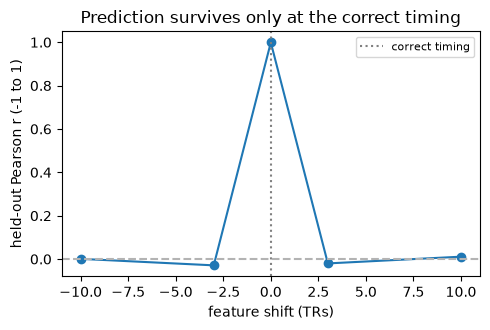

In [5]:
import matplotlib.pyplot as plt
shifts = sorted(curve); vals = [curve[s] for s in shifts]
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.plot(shifts, vals, '-o'); ax.axvline(0, ls=':', c='0.5', label='correct timing')
ax.axhline(0, ls='--', c='0.7')
ax.set_xlabel('feature shift (TRs)'); ax.set_ylabel('held-out Pearson r (-1 to 1)')
ax.set_title('Prediction survives only at the correct timing'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Reading it:** at zero shift the score is ~1.0 *because we built the targets from
the features* (a positive control). Shifting by a few TRs drops it to ~0 — the fit
depended on stimulus-locked timing. On real data, a curve that *stays* high under
shifts means the correlation was an artifact, not time-locked signal.